In [15]:
from langgraph.graph import StateGraph,START,END 
from langchain_google_genai import GoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
import os


In [32]:
class Batsman_State(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    bp: float
    summary: str

In [33]:
def sr_node(state:Batsman_State):
    """here we will count the batsmen strike rate"""

    runs=state['runs']
    balls=state['balls']

    sr=(runs/balls)*100

    return {'sr':sr}

In [41]:
def bpb_node(state:Batsman_State):
    """here we will count the batsmen ball_per_boundary"""

    four=state['fours']
    six=state['sixes']
    balls=state['balls']

    bpb=(six+four/balls)*100

    return {'bpb':bpb}

In [42]:
def bp_node(state:Batsman_State):

    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'bp': boundary_percent}

In [43]:
def summary_node(state: Batsman_State):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['bp']}
"""
    
    return {'summary': summary}

In [44]:
graph=StateGraph(Batsman_State)

graph.add_node('strike_rate', sr_node)
graph.add_node('ball_per_boundary', bpb_node)
graph.add_node('boundary_percentage', bp_node)
graph.add_node('summary', summary_node)



graph.add_edge(START, 'strike_rate')
graph.add_edge(START, 'ball_per_boundary')
graph.add_edge(START, 'boundary_percentage')

graph.add_edge('strike_rate', 'summary')
graph.add_edge('ball_per_boundary', 'summary')
graph.add_edge('boundary_percentage', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

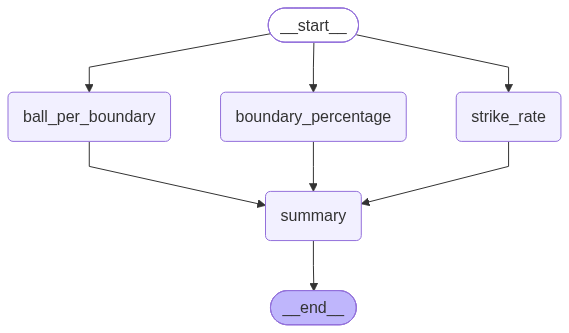

In [38]:
workflow

In [45]:
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 412.0,
 'bp': 48.0,
 'summary': '\nStrike Rate - 200.0 \n\nBalls per boundary - 412.0 \n\nBoundary percent - 48.0\n'}